In [4]:
import os
import sys
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

pd.set_option("display.max_columns", None)

In [5]:
sys.path.append(os.path.abspath("../preprocessing"))

from preprocess_churn import load_and_prepare_data

data = load_and_prepare_data()

X_test = data["X_test"]
y_test = data["y_test"]

X_test.shape, y_test.shape

((1126, 27), (1126,))

In [6]:
model = joblib.load("../../06_models/random_forest_churn_model.pkl")

model

c:\Users\84969\Desktop\Projects\Technical Projects\ML\Ecommerce_Churn_Prediction_Machine_Learning_Pipeline\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\84969\Desktop\Projects\Technical Projects\ML\Ecommerce_Churn_Prediction_Machine_Learning_Pipeline\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\84969\Desktop\Projects\T

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['tenure','city_tier','warehouse_to_home',...,'has_complaint', 'inactive_customer_flag','high_cashback_customer_flag']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

In [7]:
y_proba = model.predict_proba(X_test)[:, 1]

y_proba[:10]

array([0.005, 0.015, 0.02 , 0.   , 0.11 , 0.025, 0.035, 0.   , 0.115,
       0.   ])

In [8]:
calibration_df = pd.DataFrame({
    "actual_churn": y_test,
    "predicted_probability": y_proba
})

calibration_df["probability_bucket"] = pd.qcut(
    calibration_df["predicted_probability"],
    q=10,
    duplicates="drop"
)

calibration_summary = (
    calibration_df
    .groupby("probability_bucket", observed=True)
    .agg(
        customers=("actual_churn", "count"),
        avg_predicted_probability=("predicted_probability", "mean"),
        actual_churn_rate=("actual_churn", "mean")
    )
    .reset_index()
)

calibration_summary

,probability_bucket,customers,avg_predicted_probability,actual_churn_rate
0,"(-0.001, 0.005]",187,0.002727,0.000000
1,"(0.005, 0.01]",91,0.010000,0.000000
2,"(0.01, 0.015]",82,0.015000,0.000000
3,"(0.015, 0.025]",100,0.022300,0.000000
4,"(0.025, 0.04]",113,0.034336,0.000000
5,"(0.04, 0.065]",119,0.054118,0.000000
6,"(0.065, 0.11]",103,0.085680,0.000000
7,"(0.11, 0.27]",106,0.167358,0.000000
8,"(0.27, 0.705]",113,0.500796,0.690265
9,"(0.705, 0.985]",112,0.824196,1.000000


In [9]:
brier_score = brier_score_loss(y_test, y_proba)

calibration_metric = pd.DataFrame({
    "metric": ["brier_score"],
    "value": [brier_score]
})

calibration_metric

,metric,value
0,brier_score,0.026449


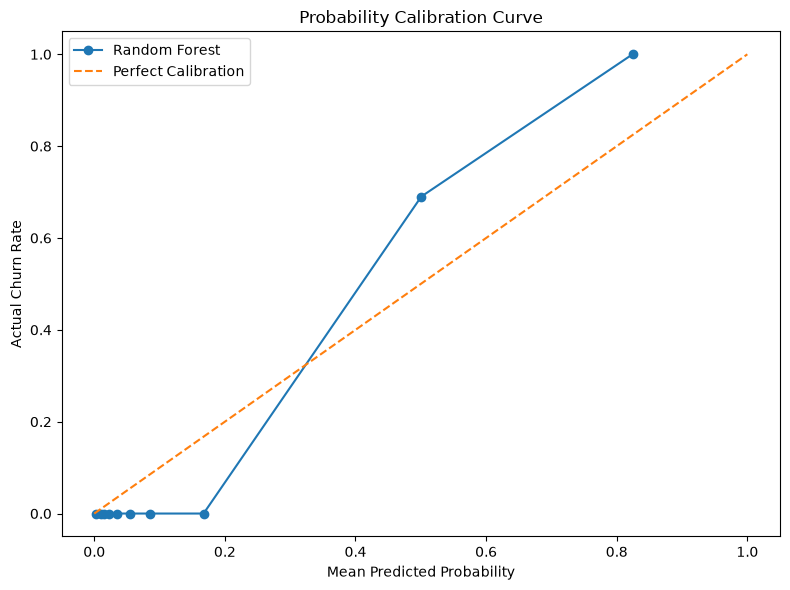

In [10]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_proba,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(8, 6))

plt.plot(prob_pred, prob_true, marker="o", label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Actual Churn Rate")
plt.title("Probability Calibration Curve")
plt.legend()
plt.tight_layout()
plt.show()

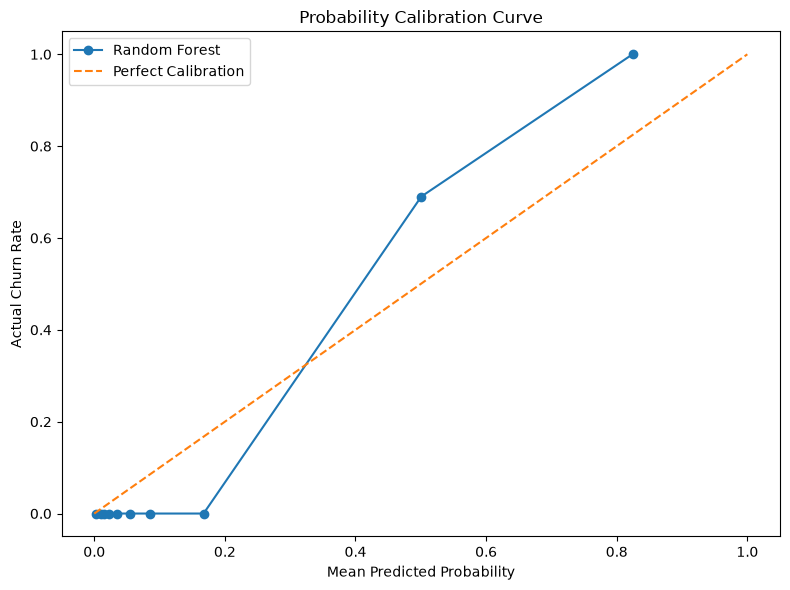

In [11]:
os.makedirs("../../05_outputs/model_results", exist_ok=True)
os.makedirs("../../05_outputs/figures", exist_ok=True)

calibration_summary.to_csv(
    "../../05_outputs/model_results/probability_calibration_summary.csv",
    index=False
)

calibration_metric.to_csv(
    "../../05_outputs/model_results/probability_calibration_metric.csv",
    index=False
)

plt.figure(figsize=(8, 6))

plt.plot(prob_pred, prob_true, marker="o", label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Actual Churn Rate")
plt.title("Probability Calibration Curve")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../../05_outputs/figures/probability_calibration_curve.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

## Probability Calibration Summary and Conclusion

A probability calibration check was added to evaluate whether the Random Forest model's predicted churn probabilities can be interpreted as absolute probabilities.

The model achieved a Brier score of 0.0264. Since a lower Brier score indicates better probability prediction, this suggests that the model's probability estimates are generally strong.

The calibration summary also shows that customers with very low predicted probabilities have an actual churn rate close to 0%. Meanwhile, customers in the highest probability bucket have an actual churn rate of 100%. This means the model is very effective at ranking customers from low churn risk to high churn risk.

However, the calibration curve shows that the predicted probabilities are not perfectly aligned with the perfect calibration line across all probability ranges. For example, in the highest probability bucket, the average predicted probability is 82.42%, while the actual churn rate is 100%. This indicates that the model underestimates churn risk for the highest-risk customers.

Therefore, in this project, the model-generated churn probability should be interpreted as a **churn risk score** rather than a fully calibrated absolute probability.

This risk score is still useful for business decision-making because it helps rank customers by churn risk and prioritize retention campaigns. However, if the business needs probabilities to represent exact real-world churn likelihood, additional calibration methods such as Platt scaling or isotonic regression should be tested in future work.

The calibration outputs were saved to:

- `05_outputs/model_results/probability_calibration_summary.csv`
- `05_outputs/model_results/probability_calibration_metric.csv`
- `05_outputs/figures/probability_calibration_curve.png`